In [ ]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from sklearn.model_selection import train_test_split

/opt/homebrew/Caskroom/miniforge/base/envs/tensorflow/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("bhavikjikadara/handwritten-digit-recognition")
print(path)

/Users/kavishkaimalsha/.cache/kagglehub/datasets/bhavikjikadara/handwritten-digit-recognition/versions/1


**Load Dataset**

In [3]:
print(os.listdir(path))

['test.csv', 'train.csv']


In [18]:
data = pd.read_csv(f'{path}/train.csv')
train_data, test_data = train_test_split(data, test_size=40, shuffle=False)

**Visualize Dataset**

In [19]:
print(train_data.head())
print(train_data.shape)
row, col = train_data.shape
print(col)

   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

In [7]:
X_train = train_data.drop('label', axis=1)
Y_train = train_data['label']
print(X_train.shape)
print(Y_train.shape)

(41980, 784)
(41980,)


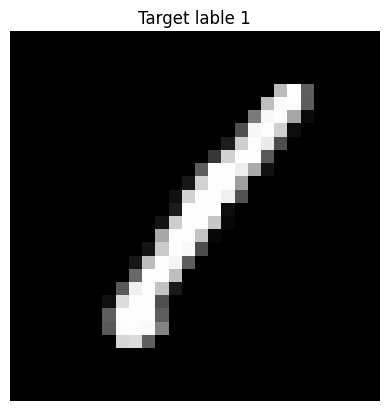

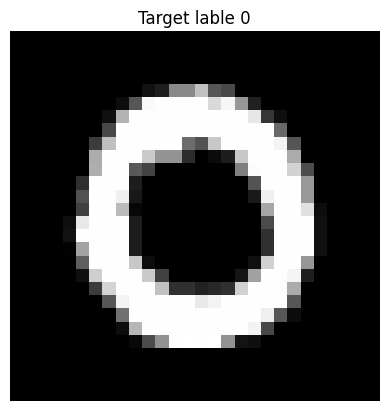

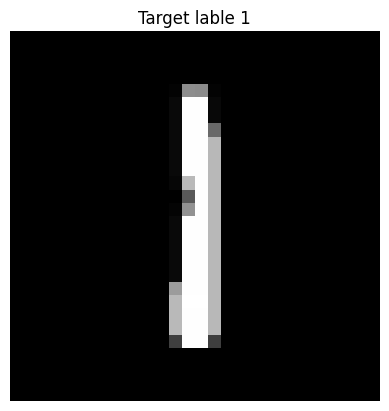

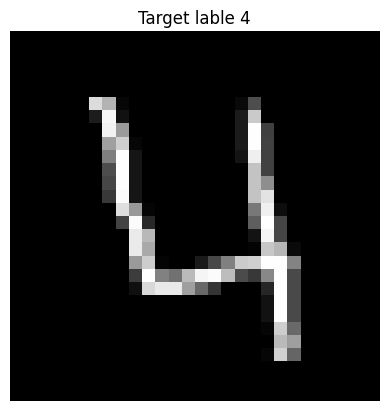

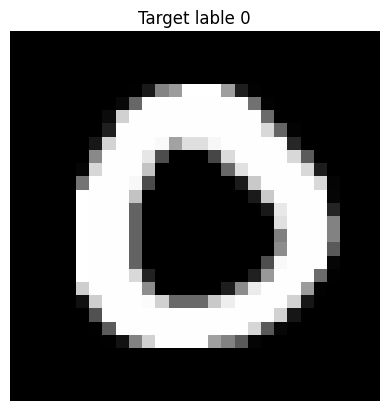

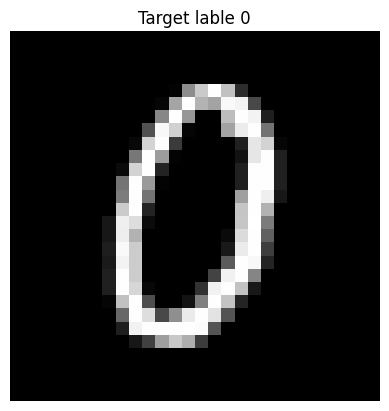

In [20]:
for i in range(6):
    pixels = X_train.iloc[i].values
    imageGrid = pixels.reshape(28,28)
    plt.imshow(imageGrid, cmap='gray')
    plt.title(f"Target lable {Y_train[i]}")
    plt.axis('off')
    plt.show()

**Preprocessing Data**

In [21]:
#Normalize data
X_train = X_train / 255.0

**Build Simple NN**

In [22]:
model = Sequential([
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [24]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

**Train model**

In [25]:
model.fit(X_train, Y_train, epochs=10)

Epoch 1/10
1312/1312 [==============================] - 1s 791us/step - loss: 1.0180
Epoch 2/10
1312/1312 [==============================] - 1s 778us/step - loss: 0.4485
Epoch 3/10
1312/1312 [==============================] - 1s 768us/step - loss: 0.3601
Epoch 4/10
1312/1312 [==============================] - 1s 774us/step - loss: 0.3237
Epoch 5/10
1312/1312 [==============================] - 1s 768us/step - loss: 0.2982
Epoch 6/10
1312/1312 [==============================] - 1s 774us/step - loss: 0.2779
Epoch 7/10
1312/1312 [==============================] - 1s 763us/step - loss: 0.2596
Epoch 8/10
1312/1312 [==============================] - 1s 759us/step - loss: 0.2438
Epoch 9/10
1312/1312 [==============================] - 1s 760us/step - loss: 0.2283
Epoch 10/10
1312/1312 [==============================] - 1s 767us/step - loss: 0.2151


In [26]:
train_predictions = model.predict(X_train)

1312/1312 [==============================] - 1s 421us/step


In [27]:
acc = SparseCategoricalAccuracy()
acc.update_state(Y_train, train_predictions)
print(f'Accuracy {acc.result().numpy()}')
acc.reset_state()
Y_train.shape

Accuracy 0.9408289790153503


(41980,)

In [28]:
X_test = test_data.drop('label', axis=1)
Y_test = test_data['label']
X_test = X_test / 255.0
test_predictions = model.predict(X_test)

2/2 [==============================] - 0s 1ms/step


In [29]:
acc.update_state(Y_test, test_predictions)
print(f'Accuracy {acc.result().numpy()}')
acc.reset_state()

Accuracy 0.949999988079071
